# Bagging Machine Learning Algorithm

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd

In [2]:
df=sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.shape

(891, 15)

In [5]:
df['pclass'].unique()

array([3, 1, 2])

In [6]:
df['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [7]:
df['sex'].unique()

array(['male', 'female'], dtype=object)

In [8]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

<Axes: >

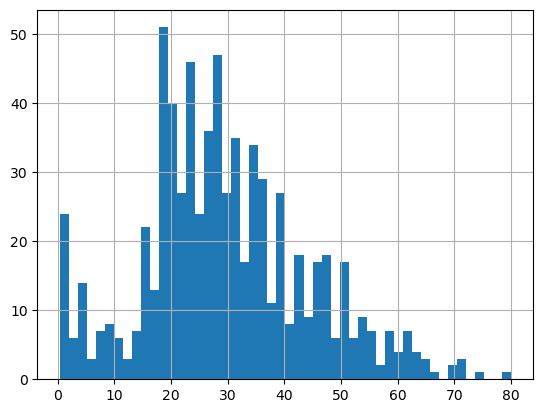

In [9]:
df['age'].hist(bins=50)

## Data Preprocessing

In [10]:
X=df[['pclass','sex','age']].copy()

In [11]:
from sklearn import preprocessing
#lb=preprocessing.LabelBinarizer()
le=preprocessing.LabelEncoder()

In [47]:
X['sex']=le.fit_transform(df['sex'])

In [13]:
X.head()

,pclass,sex,age
0,3,1,22.0
1,1,0,38.0
2,3,0,26.0
3,1,0,35.0
4,3,1,35.0


In [14]:
X.shape

(891, 3)

In [15]:
X.describe()

,pclass,sex,age
count,891.000000,891.000000,714.000000
mean,2.308642,0.647587,29.699118
std,0.836071,0.477990,14.526497
min,1.000000,0.000000,0.420000
25%,2.000000,0.000000,20.125000
50%,3.000000,1.000000,28.000000
75%,3.000000,1.000000,38.000000
max,3.000000,1.000000,80.000000


In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pclass  891 non-null    int64  
 1   sex     891 non-null    int64  
 2   age     714 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 21.0 KB


In [17]:
y=df['survived'].copy()

In [18]:
y.value_counts()

survived
0    549
1    342
Name: count, dtype: int64

## Random Forest
it is an ensemble of decision trees

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [22]:
from sklearn import preprocessing
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score

def print_score(clf, X_train, X_test, y_train, y_test, train=True):
    
    lb = preprocessing.LabelBinarizer()
    lb.fit(y_train)
    
    if train:
        res = clf.predict(X_train)
        print("Train result:\n")
        print("Accuracy score: {0:.4f}\n".format(accuracy_score(y_train, res)))
        print("Classification report:\n{}\n".format(classification_report(y_train, res)))
        print("Confusion matrix:\n{}\n".format(confusion_matrix(y_train, res)))
        print("ROC AUC: {0:.4f}\n".format(
            roc_auc_score(lb.transform(y_train), lb.transform(res))
        ))
        res=cross_val_score(clf,X_train,y_train,cv=10,scoring='accuracy')
        print("Average accuracy :\t{0:.4f}".format(np.mean(res)))
        print("Accuracy SD:\t\t{0:.4f}".format(np.std(res)))
        
    else:
        res_test = clf.predict(X_test)
        print("Test result:\n")
        print("Accuracy score: {0:.4f}\n".format(accuracy_score(y_test, res_test)))
        print("Classification report:\n{}\n".format(classification_report(y_test, res_test)))
        print("Confusion matrix:\n{}\n".format(confusion_matrix(y_test, res_test)))
        print("ROC AUC: {0:.4f}\n".format(
            roc_auc_score(lb.transform(y_test), lb.transform(res_test))
        ))


In [27]:
rf_clf=RandomForestClassifier(random_state=42,n_estimators=100)

In [28]:
rf_clf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
print_score(rf_clf,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(rf_clf,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 0.8801

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       491
           1       0.87      0.81      0.84       310

    accuracy                           0.88       801
   macro avg       0.88      0.87      0.87       801
weighted avg       0.88      0.88      0.88       801


Confusion matrix:
[[455  36]
 [ 60 250]]

ROC AUC: 0.8666

Average accuracy :	0.7839
Accuracy SD:		0.0418

************************
Test result:

Accuracy score: 0.8444

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        58
           1       0.76      0.81      0.79        32

    accuracy                           0.84        90
   macro avg       0.83      0.84      0.83        90
weighted avg       0.85      0.84      0.85        90


Confusion matrix:
[[50  8]
 [ 6 26]]

ROC AUC: 0.8373



## Grid Search

In [31]:
from sklearn.pipeline import Pipeline

In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
rf_clf=RandomForestClassifier(random_state=42,n_estimators=100)

In [35]:
params_grid={'max_depth':[3,None],
        'min_samples_split':[2,3,10],
        'min_samples_leaf':[1,3,10],
        'bootstrap':[True,False],
        'criterion':['gini','entropy']}

In [38]:
grid_search=GridSearchCV(rf_clf,params_grid,
                         n_jobs=-1,cv=5,
                         verbose=1,scoring='accuracy',
                         )

In [39]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'bootstrap': [True, False], 'criterion': ['gini', 'entropy'], 'max_depth': [3, None], 'min_samples_leaf': [1, 3, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [40]:
grid_search.best_score_

np.float64(0.7939751552795031)

In [41]:
grid_search.best_estimator_.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 3,
 'min_samples_split': 10,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [42]:
print_score(grid_search,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(grid_search,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 0.8527

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       491
           1       0.83      0.77      0.80       310

    accuracy                           0.85       801
   macro avg       0.85      0.84      0.84       801
weighted avg       0.85      0.85      0.85       801


Confusion matrix:
[[443  48]
 [ 70 240]]

ROC AUC: 0.8382

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 72 candidates, totalling 36

## Extra-trees(Extremely Randomized Trees) Ensemble

In [43]:
from sklearn.ensemble import ExtraTreesClassifier

In [44]:
xt_clf=ExtraTreesClassifier(random_state=42,n_estimators=100)

In [45]:
xt_clf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [46]:
print_score(xt_clf,X_train,X_test,y_train,y_test,train=True)
print("\n************************")
print_score(xt_clf,X_train,X_test,y_train,y_test,train=False)

Train result:

Accuracy score: 0.8814

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       491
           1       0.89      0.79      0.84       310

    accuracy                           0.88       801
   macro avg       0.88      0.86      0.87       801
weighted avg       0.88      0.88      0.88       801


Confusion matrix:
[[462  29]
 [ 66 244]]

ROC AUC: 0.8640

Average accuracy :	0.7964
Accuracy SD:		0.0406

************************
Test result:

Accuracy score: 0.8556

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89        58
           1       0.79      0.81      0.80        32

    accuracy                           0.86        90
   macro avg       0.84      0.85      0.84        90
weighted avg       0.86      0.86      0.86        90


Confusion matrix:
[[51  7]
 [ 6 26]]

ROC AUC: 0.8459

